In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("ai_jobs_global.csv")

In [4]:
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5773 entries, 0 to 5772
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   job_title         5773 non-null   object 
 1   company           5768 non-null   object 
 2   country           5773 non-null   object 
 3   city              5773 non-null   object 
 4   salary_min        3343 non-null   float64
 5   salary_max        3358 non-null   float64
 6   currency          5773 non-null   object 
 7   remote_type       5773 non-null   object 
 8   experience_level  5773 non-null   object 
 9   required_skills   1084 non-null   object 
 10  posted_date       5650 non-null   object 
 11  source            5773 non-null   object 
 12  job_description   5773 non-null   object 
dtypes: float64(2), object(11)
memory usage: 586.4+ KB


0

In [ ]:
df['average_salary'] = (df['salary_min'] + df['salary_max']) / 2
df['salary_gap'] = df['salary_max'] - df['salary_min']
df['posted_date'] = pd.to_datetime(df['posted_date'])
df['posting_year'] = df['posted_date'].dt.year
df['posting_month'] = df['posted_date'].dt.month

In [3]:
df['posted_date'] = pd.to_datetime(df['posted_date'])

In [4]:
df['posted_date'].dtype

dtype('<M8[ns]')

In [5]:
df.describe()

,salary_min,salary_max,posted_date
count,3343.000000,3358.000000,5650
mean,109240.801675,120957.415128,2025-12-25 19:25:15.185840896
min,0.000000,0.000000,2021-05-29 00:00:00
25%,77000.000000,82000.000000,2025-12-06 00:00:00
50%,99000.000000,108000.000000,2026-01-29 00:00:00
75%,133000.000000,148000.000000,2026-02-14 00:00:00
max,413000.000000,800000.000000,2026-02-22 00:00:00
std,46680.622714,58922.331934,NaN


In [6]:
df.isnull().sum()

job_title              0
company                5
country                0
city                   0
salary_min          2430
salary_max          2415
currency               0
remote_type            0
experience_level       0
required_skills     4689
posted_date          123
source                 0
job_description        0
dtype: int64

In [7]:
#Adding New Column
df['average_salary'] = (df['salary_min'] + df['salary_max']) / 2

In [8]:
#Remove Column
df.drop('job_description', axis=1, inplace=True)

In [9]:
"""Update Column
Converting posting date into datetime"""

df['posted_date'] = pd.to_datetime(df['posted_date'])

In [10]:
df['posting_year'] = df['posted_date'].dt.year

In [11]:
#Salary Minimum
df['salary_min'].describe()

count      3343.000000
mean     109240.801675
std       46680.622714
min           0.000000
25%       77000.000000
50%       99000.000000
75%      133000.000000
max      413000.000000
Name: salary_min, dtype: float64

In [12]:
#Salary Maximum
df['salary_max'].describe()

count      3358.000000
mean     120957.415128
std       58922.331934
min           0.000000
25%       82000.000000
50%      108000.000000
75%      148000.000000
max      800000.000000
Name: salary_max, dtype: float64

In [15]:
#Average Salary (Added Column)
df['average_salary'].describe()

count      3339.000000
mean     114851.602276
std       50742.777362
min           0.000000
25%       81000.000000
50%      103000.000000
75%      141000.000000
max      565000.000000
Name: average_salary, dtype: float64

In [17]:
#Job Title
df['job_title'].value_counts()

job_title
Data Scientist                                     281
AI Engineer                                        270
Machine Learning Engineer (PhD Intern)             173
Machine Learning Engineer                          110
Senior Data Scientist                              105
                                                  ... 
Director of AI Engineering                           1
Data/AI Engineer                                     1
Data & AI Engineering                                1
Senior AI Engineer (Agentic AI)                      1
Lead Clinical Laboratory Scientist - Toxicology      1
Name: count, Length: 2883, dtype: int64

In [18]:
#Country
df['country'].value_counts()

country
United States     1837
United Kingdom    1185
Canada            1068
Germany            944
Australia          739
Name: count, dtype: int64

In [19]:
#City
df['city'].value_counts()

city
London             516
Canada             379
Toronto            270
Deutschland        181
UK                 178
                  ... 
Parker               1
Village              1
Mesquite             1
Rowlett              1
Tucson, Arizona      1
Name: count, Length: 1159, dtype: int64

In [20]:
df['remote_type'].value_counts()

remote_type
Unspecified    4714
Remote          576
Hybrid          379
Onsite          104
Name: count, dtype: int64

In [21]:
df['experience_level'].value_counts()

experience_level
Mid-level     3264
Senior        1470
Lead           609
Junior         253
Management     177
Name: count, dtype: int64

In [22]:
df['currency'].value_counts()

currency
USD    5773
Name: count, dtype: int64

In [23]:
df['source'].value_counts()

source
Adzuna     5650
USAJobs     123
Name: count, dtype: int64

In [24]:
df['posting_year'].value_counts()

posting_year
2026.0    3792
2025.0    1789
2024.0      44
2023.0      22
2022.0       2
2021.0       1
Name: count, dtype: int64

In [48]:
df['salary_gap'] = df['salary_max'] - df['salary_min']

In [49]:
df['salary_gap'].describe()

count      3339.00000
mean      11262.95298
std       28021.40716
min     -142000.00000
25%           0.00000
50%           0.00000
75%        7000.00000
max      528000.00000
Name: salary_gap, dtype: float64

In [51]:
#Salary by Experience Level
df.groupby('experience_level')['average_salary'].mean().sort_values()

experience_level
Mid-level     106836.152731
Management    115423.913043
Lead          124068.181818
Junior        129710.144928
Senior        131418.918919
Name: average_salary, dtype: float64

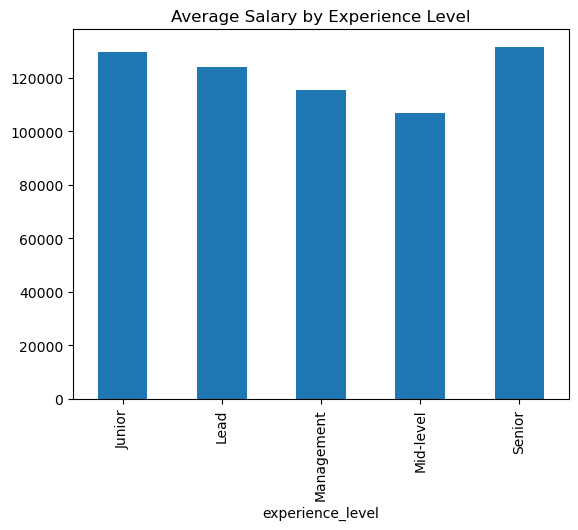

In [52]:
#visualization of the average salary by experience level
df.groupby('experience_level')['average_salary'].mean().plot(kind='bar')
plt.title('Average Salary by Experience Level')
plt.show()

In [53]:
#Remote Work vs Salary Analysis
df.groupby('remote_type')['average_salary'].mean()

remote_type
Hybrid         122671.768707
Onsite         142488.764045
Remote         108563.076923
Unspecified    113819.650323
Name: average_salary, dtype: float64

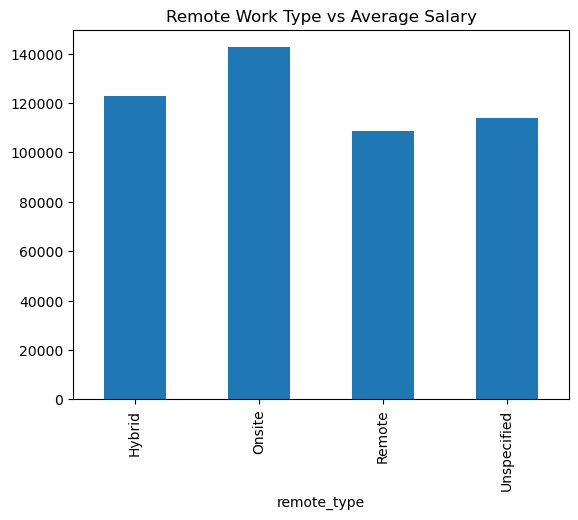

In [54]:
df.groupby('remote_type')['average_salary'].mean().plot(kind='bar')
plt.title('Remote Work Type vs Average Salary')
plt.show()

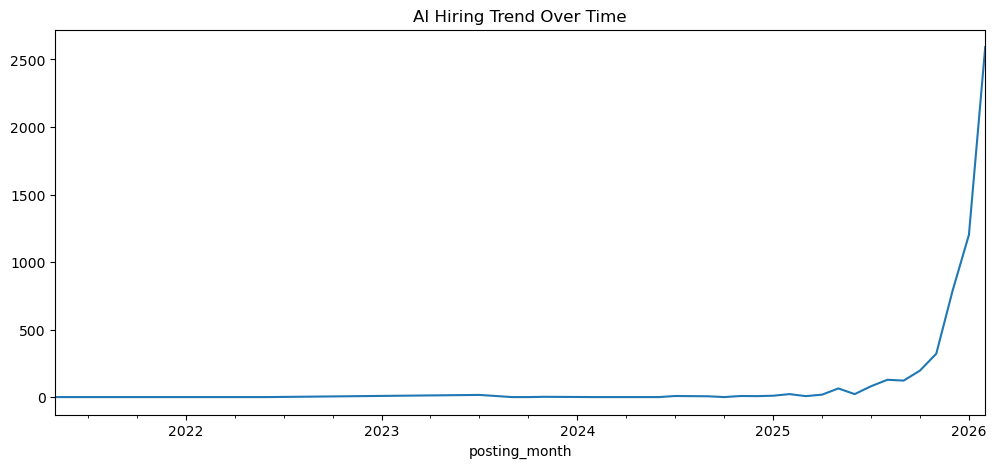

In [50]:
"""Created AI Hiring growth analysis 
Jobs created per month"""

df['posting_month'] = df['posted_date'].dt.to_period('M')
monthly_jobs = df.groupby('posting_month').size()
monthly_jobs.plot(figsize=(12,5))
plt.title('AI Hiring Trend Over Time')
plt.show()

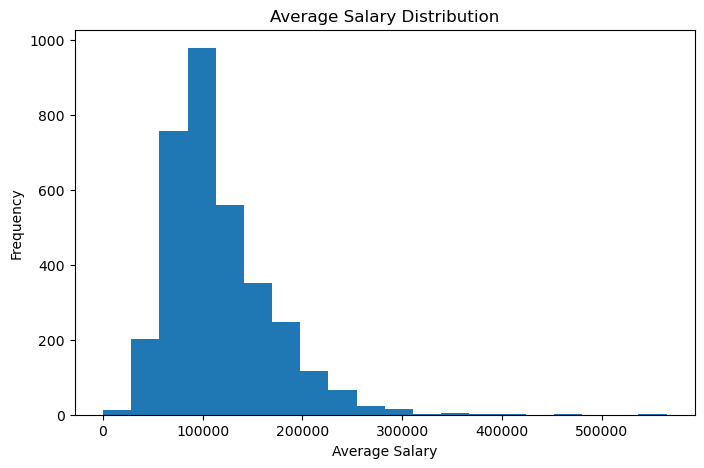

In [25]:
#Salary Distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['average_salary'].dropna(), bins=20)
plt.title('Average Salary Distribution')
plt.xlabel('Average Salary')
plt.ylabel('Frequency')
plt.show()

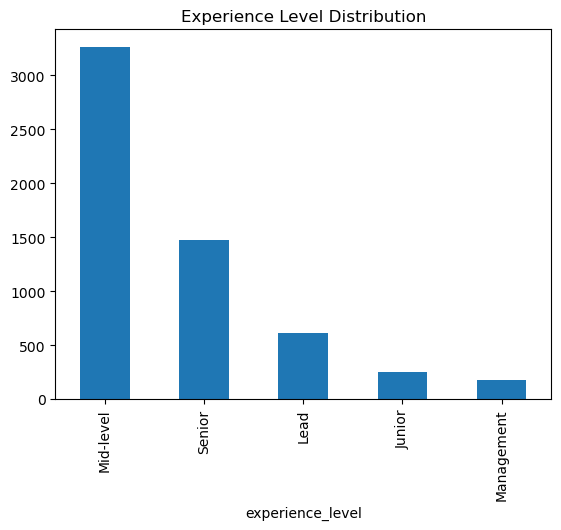

In [26]:
#Experience Level Distribution
df['experience_level'].value_counts().plot(kind='bar')
plt.title('Experience Level Distribution')
plt.show()

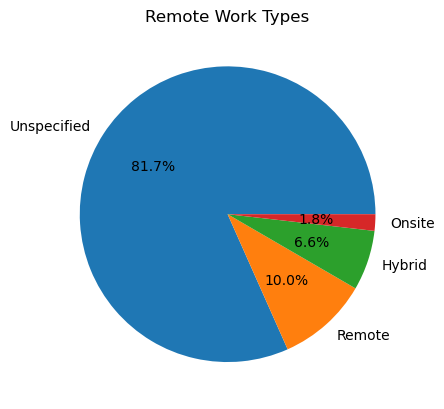

In [27]:
#Remote Work Distribution
df['remote_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Remote Work Types')
plt.show()

In [33]:
#Q1. Which are the top 5 most demanded AI job roles?
df['job_title'].value_counts().head(5)

job_title
Data Scientist                            281
AI Engineer                               270
Machine Learning Engineer (PhD Intern)    173
Machine Learning Engineer                 110
Senior Data Scientist                     105
Name: count, dtype: int64

In [34]:
#Q2. Which countries have the highest number of AI job postings?
df['country'].value_counts().head()

country
United States     1837
United Kingdom    1185
Canada            1068
Germany            944
Australia          739
Name: count, dtype: int64

In [35]:
#Q3. Which city has the highest AI hiring activity?
df['city'].value_counts().head(10)

city
London         516
Canada         379
Toronto        270
Deutschland    181
UK             178
Sydney         173
The Rocks      152
Australia      134
Berlin         125
The City        97
Name: count, dtype: int64

In [36]:
#Q4. What is the distribution of experience levels?
df['experience_level'].value_counts()

experience_level
Mid-level     3264
Senior        1470
Lead           609
Junior         253
Management     177
Name: count, dtype: int64

In [37]:
#Q5. Which recruitment source contributes the most job postings?
df['source'].value_counts()

source
Adzuna     5650
USAJobs     123
Name: count, dtype: int64

In [38]:
#Q6. What is the average minimum salary offered?
import numpy as np
np.mean(df['salary_min'].dropna())

109240.8016751421

In [39]:
#Q7. What is the average maximum salary offered?
np.mean(df['salary_max'].dropna())

120957.41512805241

In [40]:
#Q8. What is the standard deviation of average salaries?
np.std(df['average_salary'].dropna())

50735.17829416016

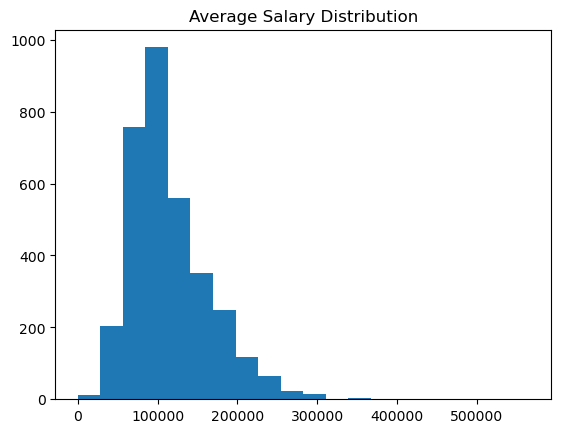

In [41]:
#Q9. What is the salary distribution among AI jobs?
plt.hist(df['average_salary'].dropna(), bins=20)
plt.title('Average Salary Distribution')
plt.show()

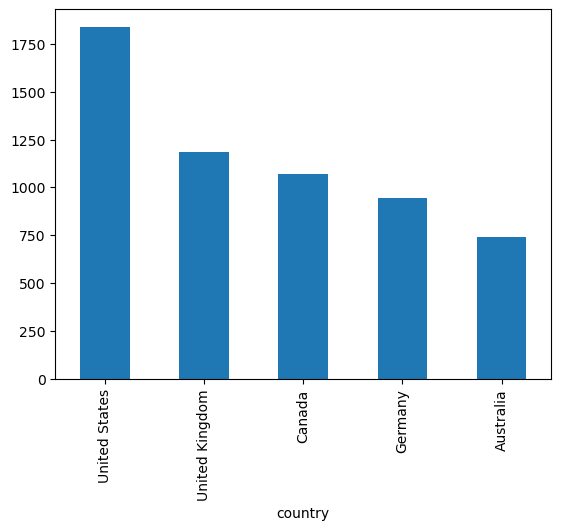

In [42]:
#Q10. Which countries have the most AI job postings?
df['country'].value_counts().head(5).plot(kind='bar')
plt.show()

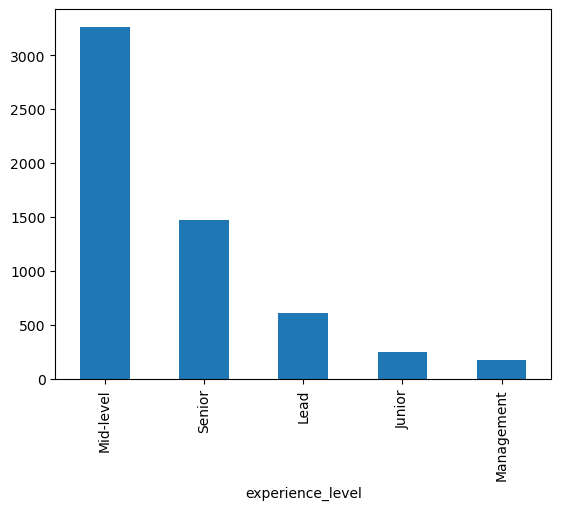

In [43]:
#Q11. How are AI jobs distributed across experience levels?
df['experience_level'].value_counts().plot(kind='bar')
plt.show()

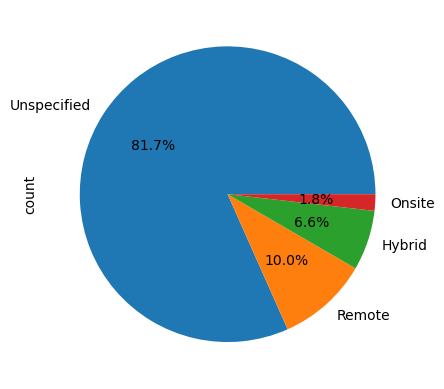

In [44]:
#Q12. What proportion of jobs are remote, hybrid, or onsite?
df['remote_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

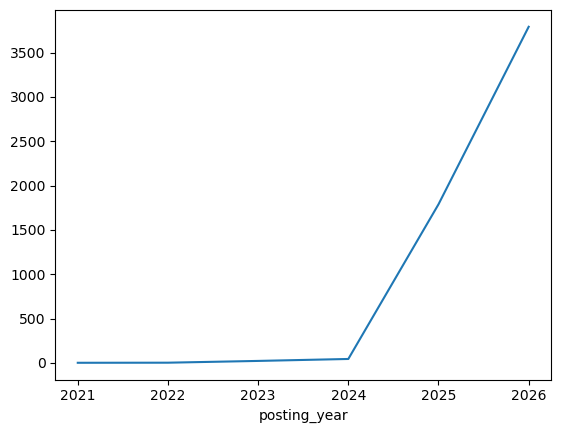

In [45]:
#Q13. How has AI hiring changed over the years?
df['posting_year'].value_counts().sort_index().plot(kind='line')
plt.show()

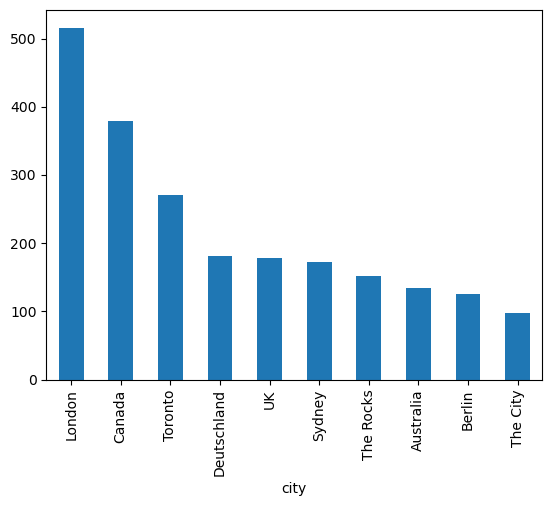

In [46]:
#Q14. Which cities have the highest AI hiring activity?
df['city'].value_counts().head(10).plot(kind='bar')
plt.show()

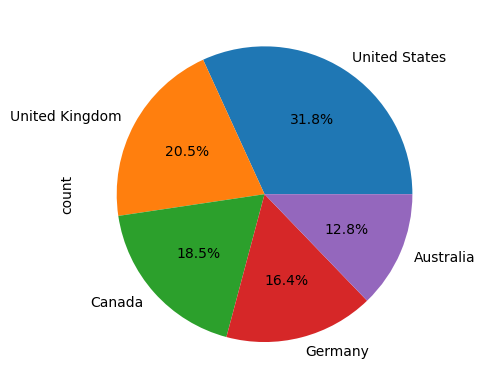

In [47]:
#Q15. What are the top countries contributing to AI employment opportunities?
df['country'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%')
plt.show()

In [6]:
df['average_salary'] = (df['salary_min'] + df['salary_max']) / 2

In [16]:
df['salary_gap'] = df['salary_max'] - df['salary_min']

In [7]:
#Country-wise Salary Ranking
country_salary = df.groupby('country')['average_salary'].mean()
country_salary.sort_values(ascending=False).head(10)

country
United States     132464.893033
Canada            105580.487805
Australia         101978.260870
United Kingdom     91381.033023
Germany            88598.360656
Name: average_salary, dtype: float64

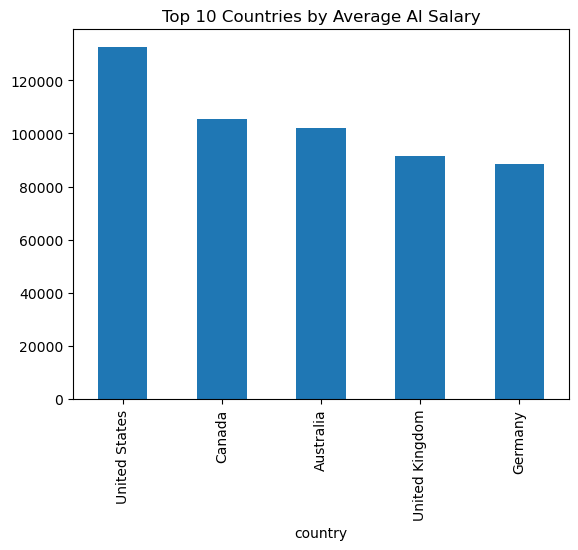

In [8]:
country_salary.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Countries by Average AI Salary')
plt.show()

In [9]:
#Created Job Demand Categories
df['salary_category'] = pd.cut(
    df['average_salary'],
    bins=[0,80000,120000,200000,1000000],
    labels=['Low','Medium','High','Very High']
)

In [10]:
df['salary_category'].value_counts()

salary_category
Medium       1326
High          980
Low           820
Very High     210
Name: count, dtype: int64

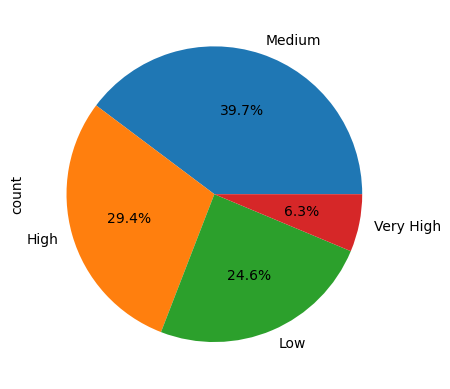

In [11]:
df['salary_category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

In [12]:
#Skill Frequency Analysis
skills = df['required_skills'].dropna()
all_skills = ','.join(skills).split(',')
skill_series = pd.Series(all_skills)
skill_series = skill_series.str.strip()
skill_series.value_counts().head(20)

Python             308
Computer Vision    276
NLP                171
Azure              133
R                  108
SQL                 87
RAG                 86
AWS                 75
OpenAI              61
Fine-tuning         32
GCP                 29
PyTorch             23
Kubernetes          23
Docker              17
Spark               15
Transformers        15
TensorFlow          13
LangChain           13
Scikit-learn         7
MLflow               6
Name: count, dtype: int64

In [13]:
#AI Job Market Concentration Index
country_share = (df['country'].value_counts()/len(df))*100
country_share.head(10)

country
United States     31.820544
United Kingdom    20.526589
Canada            18.499913
Germany           16.351983
Australia         12.800970
Name: count, dtype: float64

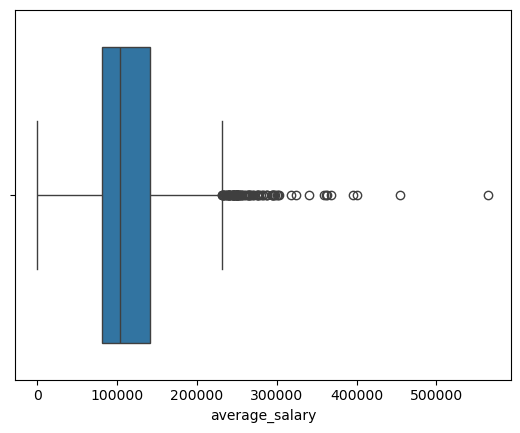

In [14]:
#Outlier Detection on Salaries
import seaborn as sns
sns.boxplot(x=df['average_salary'])
plt.show()

In [17]:
#Correlation Analysis
numeric_df = df[['salary_min','salary_max','average_salary','salary_gap']]
numeric_df.corr()

,salary_min,salary_max,average_salary,salary_gap
salary_min,1.000000,0.878811,0.962074,0.154719
salary_max,0.878811,1.000000,0.975648,0.607392
average_salary,0.962074,0.975648,1.000000,0.418354
salary_gap,0.154719,0.607392,0.418354,1.000000


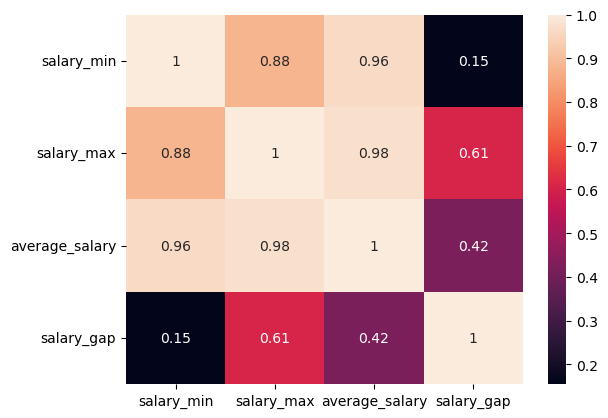

In [18]:
import seaborn as sns
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [21]:
df['posted_date'] = pd.to_datetime(df['posted_date'])

In [22]:
df['posting_year'] = df['posted_date'].dt.year

In [23]:
df[['posted_date', 'posting_year']].head()

,posted_date,posting_year
0,2026-02-16,2026.0
1,2026-02-16,2026.0
2,2026-02-16,2026.0
3,2026-02-16,2026.0
4,2026-02-16,2026.0


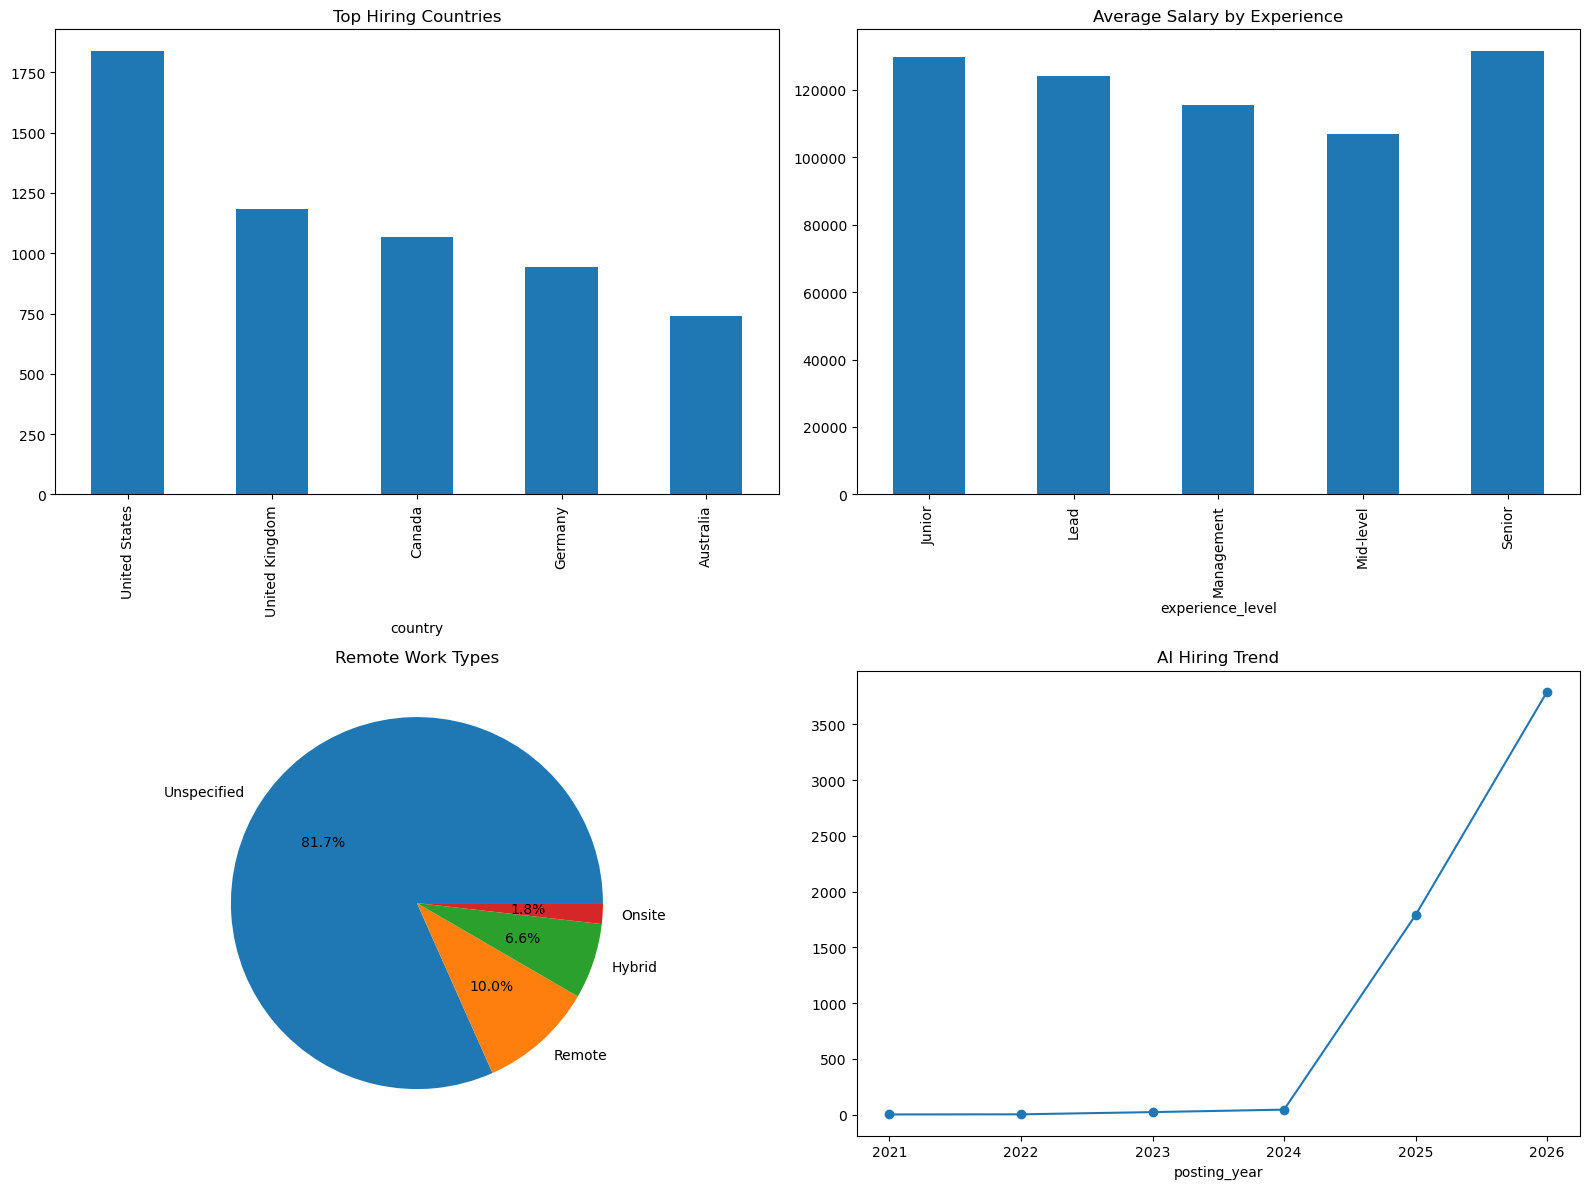

In [24]:
#Top AI Hiring Countries Dashboard
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))

plt.subplot(2,2,1)
df['country'].value_counts().head(5).plot(kind='bar')
plt.title('Top Hiring Countries')

plt.subplot(2,2,2)
df.groupby('experience_level')['average_salary'].mean().plot(kind='bar')
plt.title('Average Salary by Experience')

plt.subplot(2,2,3)
df['remote_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Remote Work Types')

plt.subplot(2,2,4)
df['posting_year'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('AI Hiring Trend')

plt.tight_layout()
plt.show()